## Functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'
import plotly.express as px
import re
import pickle
import gzip
import pandas as pd
import sys
sys.path.append('../../ViDa') 


import imp, vida.data_processing.strandReorder
imp.reload(vida.data_processing.strandReorder)
from vida.data_processing.strandReorder import *

# import imp, vida.data_processing.utils
# imp.reload(vida.data_processing.utils)
# from vida.data_processing.utils import *

import imp, vida.adjmat.dp2adj
imp.reload(vida.adjmat.dp2adj)
from vida.adjmat.dp2adj import *

import imp, vida.data_processing.comp_time
imp.reload(vida.data_processing.comp_time)
from vida.data_processing.comp_time import *


In [ ]:
def loadTimeData(datafile):
    inpath = f'../data/post_data/{datafile}/preprocess_{datafile}.npz'
    loaded_data = np.load(inpath, allow_pickle=True)
    trans_time = loaded_data["trans_time"]
    
    inpath2 = f'../data/post_data/{datafile}/time_{datafile}.npz'
    loaded_data2 = np.load(inpath2, allow_pickle=True)
    trj_id = loaded_data2['trj_id']

    rxnTimes = trans_time[trj_id]
    ids = np.arange(rxnTimes.shape[0])
    # sortTimes = np.sort(rxnTimes)[::-1]
    # sortIDs = ids[np.argsort(rxnTimes)[::-1]]
        
    return rxnTimes, ids



def loadStateData(datafile):
    
    inpath = f'../data/post_data/{datafile}/{datafile}.pkl.gz'
    with gzip.open(inpath, 'rb') as file:
        loaded_data = pickle.load(file)
    trajs_states = loaded_data['trajs_states']
    trajs_shortnames = loaded_data['trajs_shortnames']
        
    return trajs_states, trajs_shortnames



def timeCDF(datafile, rxnTimes):
    
    sort_time = np.sort(rxnTimes)
    cumulative_fraction = np.arange(1, len(sort_time) + 1) / len(sort_time)

    plt.plot(sort_time, cumulative_fraction, '-', color='black', linewidth=2)
    plt.title(f'CDF of Reaction Times: {datafile}')
    # plt.title(f'CDF of Reaction Times (Machinek-Perfect)')
    
    plt.xlabel('Reaction Time (s)')
    plt.ylabel('Cumulative Fraction of Simulated Trajectories') 
    plt.xscale('log')
    plt.grid(True)
    plt.show()

    print('Max reaction time:', np.max(rxnTimes), 'seconds')
    print('Min reaction time:', np.min(rxnTimes), 'seconds')
    print('Average reaction time:', np.mean(rxnTimes), 'seconds')
    print('Median reaction time:', np.median(rxnTimes), 'seconds')
    # thres = np.float64(1e-2)
    # print(f'Number of reaction slower than {thres}:', np.where(rxnTimes > thres)[0].shape[0])
    # print(f'Number of reaction faster than {thres}:', np.where(rxnTimes < thres)[0].shape[0])


def if_detachment(trajs_shortname):
    detach = 0
    see_attach = False

    for sname in trajs_shortname:
        if sname.count("+") == 2:
            see_attach = True
        elif sname.count("+") == 1 and see_attach:
            detach += 1
            break
        else:
            continue
        
    return detach

## Machinek-Perfect

### Time distribution sort

In [ ]:
datafile = 'Machinek-PRF'
rxnTimes, ids = loadTimeData(datafile)

In [ ]:
# fig = px.scatter(x=ids, y=sortTimes, hover_data=[sortIDs], log_y=True)
# # fig = px.scatter(x=ids, y=sortTimes, hover_data=[sortIDs])

# # plot a horizontal line for the average time
# fig.add_hline(y=np.mean(rxnTimes), line_dash="dot", line_color="red")
# fig.add_hline(y=1e-2, line_dash="dot", line_color="green")

# fig.show()

In [ ]:
timeCDF(datafile, rxnTimes)

In [ ]:
datafile = 'Machinek-PRF'
rxnTimes1, ids = loadTimeData(datafile)
sort_time1 = np.sort(rxnTimes1)
cumulative_fraction1 = np.arange(1, len(sort_time1) + 1) / len(sort_time1)

datafile = 'Machinek-Mismatch2'
rxnTimes2, ids = loadTimeData(datafile)
sort_time2 = np.sort(rxnTimes2)
cumulative_fraction2 = np.arange(1, len(sort_time2) + 1) / len(sort_time2)

datafile = 'Machinek-Mismatch2C2T'
rxnTimes3, ids = loadTimeData(datafile)
sort_time3 = np.sort(rxnTimes3)
cumulative_fraction3 = np.arange(1, len(sort_time3) + 1) / len(sort_time3)

colors = plt.cm.Set1.colors 
color1 = colors[7]
color2 = colors[3]
color3 = colors[4]

plt.figure(figsize=(8, 6))
plt.plot(sort_time1, cumulative_fraction1, '-', color='black', linewidth=3)
plt.plot(sort_time2, cumulative_fraction2, '--', color='black', linewidth=3)
plt.plot(sort_time3, cumulative_fraction3, ':', color='black', linewidth=3)
plt.xlim(3e-4, 1880)
plt.legend(['Machinek-Perfect', 'Machinek-Proximal', 'Proximal-C2T'], fontsize=12)

plt.title(f'Cumulative Distribution Function of Reaction Times', fontsize=18)
# plt.title(f'CDF of Reaction Times (Machinek-Perfect)')

plt.xlabel('Reaction Time (s)', fontsize=16)
plt.ylabel('Cumulative Fraction of Simulated Trajectories', fontsize=16) 
plt.xscale('log')
plt.grid(True)

plt.savefig("cdf.pdf")

plt.show()


### Statistics

In [ ]:
trajs_states, trajs_shortnames = loadStateData(datafile)

In [ ]:
mismatchIntraj = np.zeros(len(trajs_shortnames), dtype=int)

for i, shortnames in enumerate(trajs_shortnames):
    
    for j, name in enumerate(shortnames):
        if name == 'inv+sub+incb':
            inv, sub, _ = trajs_states[i][j].split('+')
            
            # identify the mismatched strand
            if '))))' in sub[0:5] and '((((' in inv:
                # if sub[0] == ')' or sub[1] == ')' or sub[2] == ')':
                mismatchIntraj[i] = 1 
                
                
                # if i in [275, 117, 287, 270, 259]:
                #     print(i)
                #     print(trajs_states[i][j])
                #     print(sub, inv)
                # break
            
        if name == 'incb+sub+inv': 
            _, sub, inv = trajs_states[i][j].split('+') 
            
            # identify the mismatched strand
            if '((((' in sub[0:5] and '))))' in inv:
                mismatchIntraj[i] = 1 
                break   
    

In [ ]:
traj_mismatch = np.where(mismatchIntraj == 1)[0]
traj_mismatch.shape[0], traj_mismatch

In [ ]:
traj_no_mismatch = np.where(mismatchIntraj == 0)[0]

traj_no_mismatch.shape[0], traj_no_mismatch

In [ ]:
print('Average reaction time for trajectories with mismatch:', np.mean(rxnTimes[traj_mismatch]), 'seconds') 
print('Average reaction time for trajectories without mismatch:', np.mean(rxnTimes[traj_no_mismatch]), 'seconds')

In [ ]:
# np.sort(rxn_times[traj_mismatch])[:10], traj_mismatch[np.argsort(rxn_times[traj_mismatch])[:5]]

In [ ]:
# Count for hairpins in Non-mismatched reactions
hairpinInmatch = np.zeros(len(traj_no_mismatch), dtype=int)

for i, idx in enumerate(traj_no_mismatch):
    for j, name in enumerate(trajs_shortnames[idx]):
        if name == 'inv+sub+incb':
            inv, _, _ = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmatch[i] = 1
                break
        
        if name == 'incb+sub+inv':
            _, _, inv = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmatch[i] = 1
                break
        
        if name == 'incb+sub inv':
            _, _, inv = re.split(r'\s|\+', trajs_states[idx][j]) 
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmatch[i] = 1
                break
    

In [ ]:
print(f'{np.where(hairpinInmatch==1)[0].shape[0]} hairpins in {traj_no_mismatch.shape[0]} Non-mismatched reactions')

In [ ]:
print('The index of Non-mismatched reactions with hairpins:')
hp_nonmismatch_index = traj_no_mismatch[np.where(hairpinInmatch==1)[0]]
nohp_nonmismatch_index = traj_no_mismatch[np.where(hairpinInmatch==0)[0]]
hp_nonmismatch_index, nohp_nonmismatch_index

In [ ]:
print('The overall average time of Non-mismatched reactions:')
print(np.mean(rxnTimes[traj_no_mismatch]))
print()
print('The average time of Non-mismatched reactions with Hairpins:')
print(np.mean(rxnTimes[hp_nonmismatch_index]))
print()
print('The average time of Non-mismatched reactions without Hairpins:')
print(np.mean(rxnTimes[traj_no_mismatch[np.where(hairpinInmatch==0)[0]]]))


In [ ]:
# Count for hairpins in Mismatched reactions

hairpinInmismatch = np.zeros(len(traj_mismatch), dtype=int)

for i, idx in enumerate(traj_mismatch):
    for j, name in enumerate(trajs_shortnames[idx]):
        if name == 'inv+sub+incb':
            inv, _, _ = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmismatch[i] = 1
                break
        
        if name == 'incb+sub+inv':
            _, _, inv = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmismatch[i] = 1
                break
        
        if name == 'incb+sub inv':
                _, _, inv = re.split(r'\s|\+', trajs_states[idx][j]) 
                
                if '(((' in inv[6:17] and ')))' in inv[6:17]:
                    hairpinInmismatch[i] = 1
                    break

In [ ]:
print(f'{np.where(hairpinInmismatch==1)[0].shape[0]} hairpins in {traj_mismatch.shape[0]} Non-mismatched reactions')

In [ ]:
print('The index of Mismatched reactions with hairpins:')
hp_mismatch_index = traj_mismatch[np.where(hairpinInmismatch==1)[0]]
hp_mismatch_index

In [ ]:
print('The average time of Mismatched reactions with hairpins:', np.mean(rxnTimes[hp_mismatch_index]))

### Detailed plots

In [ ]:
import matplotlib.pyplot as plt

# Data for the first pie chart
labels1 = ['Non-misstack', 'Misstack']
sizes1 = [traj_no_mismatch.shape[0], traj_mismatch.shape[0]]

# Data for the second pie chart
label2 = ['Non-misstack w/ hairpins', 'Non-misstack w/o hairpins']
size2 = [hp_nonmismatch_index.shape[0], traj_no_mismatch.shape[0] - hp_nonmismatch_index.shape[0]]

# Data for the third pie chart
label3 = ['Misstack w/ hairpins', 'Misstack w/o hairpins']
size3 = [hp_mismatch_index.shape[0], traj_mismatch.shape[0] - hp_mismatch_index.shape[0]]


fig, ax = plt.subplots(1, 3, figsize=(50, 30)) 
# First pie chart
color_hairpin = ['yellowgreen', 'tomato']
ax[0].pie(size2, labels=label2, autopct='%1.2f%%', shadow=True, startangle=90,  colors=color_hairpin, textprops={'fontsize': 30})
ax[0].set_title('Non-misstack w/wo Hairpins')
ax[0].title.set_size(50)
# Second pie chart
ax[1].pie(sizes1, labels=labels1, autopct='%1.2f%%', shadow=True, startangle=90, textprops={'fontsize': 30})
ax[1].set_title('Misstack Percentage')
# title size
ax[1].title.set_size(50)
# Third pie chart
ax[2].pie(size3, labels=label3, autopct='%1.1f%%', shadow=True, startangle=90, colors=color_hairpin, textprops={'fontsize': 30})
ax[2].set_title('Misstack w/wo Hairpins')
ax[2].title.set_size(50)
# Adjust the layout to prevent overlap
plt.tight_layout()
plt.show()

print(f'                                         {np.where(hairpinInmismatch==1)[0].shape[0]} hairpins in {traj_mismatch.shape[0]} Non-misstack reactions')
print(f'                                         {np.where(hairpinInmatch==1)[0].shape[0]} hairpins in {traj_no_mismatch.shape[0]} Non-misstack reactions')


In [ ]:
fig, ax = plt.subplots(figsize=(7,7))
time_names = ['Overall', 'Fast mode', 'Slow mode']
bar_colors = ['orangered', 'skyblue', 'skyblue']
average_times = [np.mean(rxnTimes), np.mean(rxnTimes[traj_no_mismatch]), np.mean(rxnTimes[traj_mismatch])]
bars = ax.bar(time_names, average_times, color=bar_colors)
ax.set_title('Average Reaction Time', fontsize=15)
ax.set_ylabel('Time (s)', fontsize=15)
ax.set_xticklabels(time_names, fontsize=15)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', ha='center', va='bottom', fontsize=15)


In [ ]:
print("Conclusion: \n Hairpin structures severs as two roles:\n \
1. If hairpins form first, then they will prevent the reaction to form mismatches, speeding up the reaction.\n \
2. If mismatches happen first, then hairpins will serve as 'escape route', to help reaction trajectories \n \
   escape from the kinetic traps towards the final state. \n") 

### PCA Variance

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
# Load embeddings

datafile='Machinek-PRF-trunc'

TNAME = '24-0324-0120'
CKPT = 'checkpoint_epoch_39'
# CKPT = 'model'

inpath5 = f'../data/post_data/{datafile}/model_config/{TNAME}/embed_{CKPT}_Machinek-PRF.npz'
loaded_data5 = np.load(inpath5, allow_pickle=True)
embeddings = loaded_data5['embeddings']
embeddings.max(), embeddings.min(), embeddings.mean(), embeddings.std()

In [ ]:
cm = PCA(n_components=25)
cm.fit(embeddings)

PC_values = np.arange(cm.n_components_) + 1
plt.plot(PC_values, np.cumsum(cm.explained_variance_ratio_), 'ro-', linewidth=2)
plt.title('Scree Plot: PCA')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance');
# plt.xticks(np.arange(0, data_embed.shape[-1]+1, 1))

plt.show()

print(np.cumsum(cm.explained_variance_ratio_))

## Machinek-MM14

### Time distribution plot

In [ ]:
datafile = 'Machinek-Mismatch14'
rxnTimes, ids = loadTimeData(datafile)

In [ ]:
timeCDF(datafile, rxnTimes)

## Machinek-MM14C2T

In [ ]:
datafile = 'Machinek-Mismatch14C2T'
rxnTimes, ids = loadTimeData(datafile)

In [ ]:
timeCDF(datafile, rxnTimes)

## Machinek-MM10

In [ ]:
datafile = 'Machinek-Mismatch10'
rxnTimes, ids = loadTimeData(datafile)

In [ ]:
timeCDF(datafile, rxnTimes)

## Machinek-MM2

In [ ]:
datafile = 'Machinek-Mismatch2'
rxnTimes, ids = loadTimeData(datafile)

In [ ]:
timeCDF(datafile, rxnTimes)

## Machinek-MM2C2A

In [ ]:
datafile = 'Machinek-Mismatch2C2A'
rxnTimes, ids = loadTimeData(datafile)

In [ ]:
timeCDF(datafile, rxnTimes)

## Machinek-MM2C2T

In [ ]:
datafile = 'Machinek-Mismatch2C2T'
rxnTimes, ids = loadTimeData(datafile)

In [ ]:
timeCDF(datafile, rxnTimes)

## Detachment Probability

In [ ]:
# datafile = 'Machinek-PRF'
datafile = 'Machinek-Mismatch2C2A'

trajs_states, trajs_shortnames = loadStateData(datafile)

In [ ]:
set(trajs_shortnames[0]), set(trajs_shortnames[10])

In [ ]:
count_list = []
for i in range(200):
    count_list.append(if_detachment(trajs_shortnames[i]))
    
prob = sum(np.array(count_list) == 1) / len(count_list)
prob

In [ ]:
set(trajs_shortnames[1])

## Jordan's data

In [ ]:
import h5py as h5

def read_trajectory(traj_filename, sim_no): 
    with h5.File(traj_filename, "r") as f:
        times = f[str(sim_no)]["times"][:]
        energies = f[str(sim_no)]["energies"][:]
        structs = [s.decode() for s in f[str(sim_no)]["structs"]]
        ids = [s.decode() for s in f[str(sim_no)]["ordered_ids"]]
    return times, energies, structs, ids

In [ ]:
fdata = '../data/raw_data/machinektest/perfect_toehold8_conc10_54222558.hdf5'

In [ ]:
traj0 = read_trajectory(fdata, 0)

In [ ]:
times = traj0[0]
times.shape, times[:5]

In [ ]:
energies = traj0[1]
energies.shape, energies[:5]

In [ ]:
strucs = traj0[2]
len(strucs), strucs[:5]


In [ ]:
ids = traj0[3]
len(ids), ids[:5]

In [ ]:
traj555 = read_trajectory(fdata, 555)

In [ ]:
traj555[3]

In [ ]:
traj555[2]

In [ ]:
traj2 = read_trajectory(fdata, 2)

In [ ]:
traj2[2], traj2[3]

### Jordan Data

In [ ]:
import h5py as h5
import numpy as np

def read_trajectory(traj_filename, sim_no): 
    with h5.File(traj_filename, "r") as f:
        times = f[str(sim_no)]["times"][:]
        energies = f[str(sim_no)]["energies"][:]
        structs = [s.decode() for s in f[str(sim_no)]["structs"]]
        ids = [s.decode() for s in f[str(sim_no)]["ordered_ids"]]
    return times, energies, structs, ids

def parse_cids(cids):
  # decode strand IDs
  sids = [np.array(c.split(b'+'), dtype=int) // 2 for c in cids]
  smin = np.concatenate(sids).min()
  sids = [(c - smin).tolist() for c in sids]
  # find minimal cyclic permutation per complex
  prm_parts = lambda c: lambda p: (c[p:len(c)], c[0:p])
  prm = lambda c: lambda p: sum(prm_parts(c)(p), start=[])
  argprm = lambda c: min(np.atleast_1d(np.argmin(c)), key=prm(c))
  return [tuple(prm(c)(argprm(c))) for c in sids]

# [parse_cids(cids.encode(encoding='utf-8').split(b' ')) for cids in [ids[0], ids[-1]]]

In [ ]:
file = f'../data/raw_data/machinektest/perfect_toehold7_dangle.hdf5'
times, energies, structs, ids = read_trajectory(file, 20)

In [ ]:
[parse_cids(cids.encode(encoding='utf-8').split(b' ')) for cids in [ids[0], ids[-1]]]

In [ ]:
[parse_cids(cids.encode(encoding='utf-8').split(b' ')) for cids in [ids[0], ids[-1]]]

### Stats

In [1]:
import re
import pickle
import gzip
import numpy as np
import matplotlib.pyplot as plt



def loadData(datafile):
    inpath = f'../data/post_data/{datafile}/preprocess_{datafile}.npz'
    loaded_data = np.load(inpath, allow_pickle=True)
    trans_time = loaded_data["trans_time"]
    indices_all = loaded_data["indices_all"]
    dp_og_uniq = loaded_data["dp_og_uniq"]
    id_uniq = loaded_data["id_uniq"]
    dp_og = dp_og_uniq[indices_all]
    order_id = id_uniq[indices_all]
    
    inpath2 = f'../data/post_data/{datafile}/time_{datafile}.npz'
    loaded_data2 = np.load(inpath2, allow_pickle=True)
    trj_id = loaded_data2['trj_id']
    
    rxnTimes = trans_time[trj_id]
    
    arrays_to_split = [dp_og, order_id]
    subtrj_id = (trj_id+1)[:-1]
    sub_arrays = [np.split(arr, subtrj_id) for arr in arrays_to_split]
    
    trajs_states, trajs_order = sub_arrays
    
    return rxnTimes, np.array(trajs_states,dtype='object'), np.array(trajs_order,dtype='object')



def timeCDF(datafile, rxnTimes):
    
    sort_time = np.sort(rxnTimes)
    cumulative_fraction = np.arange(1, len(sort_time) + 1) / len(sort_time)

    plt.plot(sort_time, cumulative_fraction, '-', color='black', linewidth=2)
    plt.title(f'CDF of Reaction Times: {datafile}')
    # plt.title(f'CDF of Reaction Times (Machinek-Perfect)')
    
    plt.xlabel('Reaction Time (s)')
    plt.ylabel('Cumulative Fraction of Simulated Trajectories') 
    plt.xscale('log')
    plt.grid(True)
    plt.show()

    print('Max reaction time:', np.max(rxnTimes), 'seconds')
    print('Min reaction time:', np.min(rxnTimes), 'seconds')
    print('Average reaction time:', np.mean(rxnTimes), 'seconds')
    print('Median reaction time:', np.median(rxnTimes), 'seconds')
    # thres = np.float64(1e-2)
    # print(f'Number of reaction slower than {thres}:', np.where(rxnTimes > thres)[0].shape[0])
    # print(f'Number of reaction faster than {thres}:', np.where(rxnTimes < thres)[0].shape[0])
    
    
    
def misstack(sort_idx, sort_trajs_states):
    num_misstack = 0
    traj_idx = []
    for idx, traj in zip(sort_idx, sort_trajs_states):
        traj = trajs_states[idx]
        for states in traj:
            inv = states.split('+')[1]
            sub = states.split('+')[2]
            if inv[9:13].count('(') >= 3 and inv[13:24].count('.') >= 8 and sub[1:5].count(')') >= 3 and sub[5:10].count('.') >=2: 
                num_misstack += 1  
                traj_idx.append(idx)
                break       
    return num_misstack, traj_idx



def misstack_nodangle(sort_idx, sort_trajs_states, sort_trajs_order):
    num_misstack = 0
    traj_idx = []

    for idx, traj_state, traj_order in zip(sort_idx, sort_trajs_states, sort_trajs_order):
        for state, order in zip(traj_state, traj_order):
            if order == [(0, 1, 2)]:
                inv = state.split('+')[2]
                sub = state.split('+')[1]
            elif order == [(0, 1), (2,)]:
                inv = state.split(' ')[1]
                inc_sub = state.split(' ')[0]
                sub = inc_sub.split('+')[1]
            elif order == [(0,), (1, 2)]:
                sub_inv = state.split(' ')[1]
                inv = sub_inv.split('+')[1]
                sub = sub_inv.split('+')[0]
            elif order == [(0, 2, 1)]:
                inv = state.split('+')[1]
                sub = state.split('+')[2]
            elif order == [(0, 2), (1,)]:
                inc_inv = state.split(' ')[0]
                inv = inc_inv.split('+')[1]
                sub = state.split(' ')[1]
            elif order == [(0,), (2, 1)]:
                inv_sub = state.split(' ')[1]
                inv = inv_sub.split('+')[0]
                sub = inv_sub.split('+')[1]
            else:
                raise ValueError("Invalid order")
            
            if inv[9:13].count('(') >= 3 and inv[13:24].count('.') >= 8 and sub[1:5].count(')') >= 3 and sub[5:10].count('.') >=2: 
                    num_misstack += 1  
                    traj_idx.append(idx)
                    break
                
    return num_misstack, traj_idx


In [2]:
# datafile = 'proximal_toehold8'
datafile = 'perfect_toehold7_dangle_CC2GG'
rxnTimes, trajs_states, trajs_order= loadData(datafile)
sort_idx = np.argsort(rxnTimes)[::-1]
sort_rxnTimes = rxnTimes[sort_idx]
sort_trajs_states = trajs_states[sort_idx]
sort_trajs_order = trajs_order[sort_idx]
sort_final_states = [arr[-1] for arr in sort_trajs_states]
sort_final_order = [arr[-1] for arr in sort_trajs_order]

In [3]:
num_succ = 0
sort_succ_traj_id = []
sort_unsucc_traj_id = []
for idx, order in zip(sort_idx, sort_final_order):
    if (0,) in order:
        sort_succ_traj_id.append(idx)
        num_succ += 1
    else:
        sort_unsucc_traj_id.append(idx)

print(datafile)
print('Total number of trajectories::', len(sort_trajs_states))
print('Number of successful trajectories:', num_succ)
print('Fraction of successful/unsuccessful:', round(num_succ / (len(sort_trajs_states)-num_succ), 3))
print('The index of successful trajectories:', sort_succ_traj_id)

rxnTimes_succ = rxnTimes[sort_succ_traj_id]
print('Mean reaction time for successful trajs:', round(np.mean(rxnTimes_succ),5), 'seconds')
rxnTimes_unsucc = rxnTimes[sort_unsucc_traj_id]
print('Mean reaction time for unsuccessful trajs:', round(np.mean(rxnTimes_unsucc),5), 'seconds')

# find how many misstacked trajectories
num_misstack, traj_idx = misstack_nodangle(sort_idx, sort_trajs_states, sort_trajs_order)
# find how many successful trajectories are misstacked
num_succ_misstack = 0
succ_misstack_idx = []
for idx in traj_idx:
    if idx in sort_succ_traj_id:
        succ_misstack_idx.append(idx)
        num_succ_misstack += 1

print('Number of successful misstacked trajectories:', num_succ_misstack, ':', succ_misstack_idx)
print('Fraction of successful misstacked trajectories over all successful trajectories:', round(num_succ_misstack / num_succ, 3)) 
print('Total number of misstacked trajectories:', num_misstack) 

perfect_toehold7_dangle_CC2GG
Total number of trajectories:: 400
Number of successful trajectories: 27
Fraction of successful/unsuccessful: 0.072
The index of successful trajectories: [230, 368, 131, 281, 237, 277, 159, 262, 343, 25, 247, 60, 45, 206, 168, 304, 152, 271, 113, 178, 394, 2, 101, 194, 204, 305, 173]
Mean reaction time for successful trajs: 0.00399 seconds
Mean reaction time for unsuccessful trajs: 9e-05 seconds
Number of successful misstacked trajectories: 0 : []
Fraction of successful misstacked trajectories over all successful trajectories: 0.0
Total number of misstacked trajectories: 4


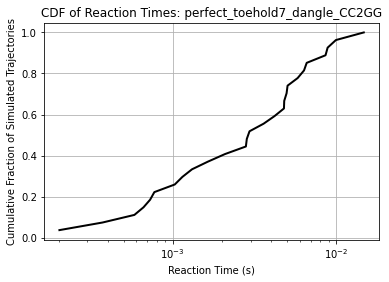

Max reaction time: 0.014782348966501452 seconds
Min reaction time: 0.00020241888242758106 seconds
Average reaction time: 0.003986274179767553 seconds
Median reaction time: 0.0029521781949257914 seconds


In [4]:
rxnTimes_succ = rxnTimes[sort_succ_traj_id]
timeCDF(datafile, rxnTimes_succ)

In [387]:
# 0: incumbent
# 1: substrate
# 2: invader

num_misstack = 0
traj_idx = []

for idx, traj_state, traj_order in zip(sort_idx, sort_trajs_states, sort_trajs_order):
    for state, order in zip(traj_state, traj_order):
        if order == [(0, 1, 2)]:
            inv = state.split('+')[2]
            sub = state.split('+')[1]
        elif order == [(0, 1), (2,)]:
            inv = state.split(' ')[1]
            inc_sub = state.split(' ')[0]
            sub = inc_sub.split('+')[1]
        elif order == [(0,), (1, 2)]:
            sub_inv = state.split(' ')[1]
            inv = sub_inv.split('+')[1]
            sub = sub_inv.split('+')[0]
        elif order == [(0, 2, 1)]:
            inv = state.split('+')[1]
            sub = state.split('+')[2]
        elif order == [(0, 2), (1,)]:
            inc_inv = state.split(' ')[0]
            inv = inc_inv.split('+')[1]
            sub = state.split(' ')[1]
        elif order == [(0,), (2, 1)]:
            inv_sub = state.split(' ')[1]
            inv = inv_sub.split('+')[0]
            sub = inv_sub.split('+')[1]
        else:
            raise ValueError("Invalid order")
        
        if inv[9:13].count('(') >= 3 and inv[13:24].count('.') >= 8 and sub[1:5].count(')') >= 3 and sub[5:10].count('.') >=2: 
                num_misstack += 1  
                traj_idx.append(idx)
                break


In [388]:
num_misstack

142

In [389]:
traj_idx

[822,
 165,
 596,
 410,
 503,
 649,
 944,
 493,
 650,
 337,
 266,
 247,
 48,
 830,
 192,
 950,
 655,
 887,
 436,
 475,
 391,
 426,
 84,
 612,
 6,
 982,
 274,
 90,
 223,
 779,
 606,
 341,
 933,
 394,
 521,
 114,
 780,
 210,
 369,
 551,
 0,
 403,
 641,
 687,
 644,
 808,
 62,
 53,
 284,
 928,
 588,
 740,
 858,
 51,
 16,
 866,
 576,
 966,
 381,
 978,
 541,
 423,
 603,
 182,
 989,
 310,
 270,
 37,
 412,
 805,
 56,
 683,
 456,
 470,
 128,
 815,
 838,
 108,
 91,
 975,
 929,
 705,
 515,
 516,
 183,
 939,
 387,
 371,
 203,
 898,
 536,
 594,
 695,
 139,
 33,
 484,
 809,
 946,
 656,
 696,
 535,
 952,
 27,
 879,
 132,
 402,
 957,
 306,
 590,
 411,
 634,
 992,
 23,
 633,
 832,
 285,
 329,
 398,
 365,
 731,
 640,
 160,
 425,
 492,
 79,
 361,
 974,
 534,
 681,
 943,
 730,
 406,
 328,
 527,
 258,
 907,
 332,
 476,
 454,
 859,
 624,
 995]